# STAGE 09 — FAVOURABILITY 30 RULES

Проверяем отдельное определение good day с коротким 30-quote контекстом. `favourability_percentile_30` использует строго `T-30…T-1`; текущая котировка исключена. Ground truth: `GT_30 = favourability_percentile_30 >= 0.85 AND actual_regret_5 <= 0.005`. Forecasting-модели не переобучаются.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.favourability_30_rules import plot_test, run_favourability_30
required=['reports/good_day_features_validation.csv','reports/good_day_features.csv','reports/per_corridor_good_day_test_results.csv','data/features/base_market_features.parquet']
inventory=pd.DataFrame({'artifact':required,'exists':[(ROOT/p).exists() for p in required]})
display(inventory)
if not inventory.exists.all(): raise FileNotFoundError(inventory.loc[~inventory.exists,'artifact'].tolist())
run=run_favourability_30(ROOT,make_plots=False)
print('Validation rows:',len(run['validation']),'Test rows:',len(run['test']))
print('Forecasting retrained: NO')

,artifact,exists
0,reports/good_day_features_validation.csv,True
1,reports/good_day_features.csv,True
2,reports/per_corridor_good_day_test_results.csv,True
3,data/features/base_market_features.parquet,True


Validation rows: 1370 Test rows: 1375
Forecasting retrained: NO


## 1. Causal favourability 30

Признак рассчитан один раз на полном историческом quote-time ряду внутри каждого corridor. До каждой даты T используются только 30 предыдущих наблюдений; warm-up остаётся NaN, но validation/test расположены после него.

In [2]:
display(run['validation'][['corridor','date','rate_t','favourability_percentile_30']].head())
print('Validation range:',run['validation'].date.min().date(),'—',run['validation'].date.max().date())
print('Test range:',run['test'].date.min().date(),'—',run['test'].date.max().date())

,corridor,date,rate_t,favourability_percentile_30
0,AMD_RUB,2024-05-23,0.232224,1.000000
1,AMD_RUB,2024-05-24,0.232852,0.966667
2,AMD_RUB,2024-05-25,0.231329,1.000000
3,AMD_RUB,2024-05-28,0.228552,1.000000
4,AMD_RUB,2024-05-29,0.227914,1.000000


Validation range: 2024-05-23 — 2025-06-28
Test range: 2025-07-12 — 2026-08-20


## 2. Validation-only rule selection

Для каждого коридора проверены ровно 48 правил. Требуется uplift > 1. При practical tie менее 0.05 используются hit rate, число сигналов и простота. Частота сигналов не входит в selection criterion.

In [3]:
print('Validation candidates:',len(run['candidates']))
display(run['selection'])

Validation candidates: 240


,corridor,selected_rule,F,A,R,validation_frequency,validation_hit_rate,validation_uplift,status
0,AMD_RUB,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,0.094891,0.461538,3.030303,VALIDATED_RULE
1,KGS_RUB,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,0.109489,0.400000,2.931596,VALIDATED_RULE
2,KZT_RUB,F=0.800|A=0.005|R=0.002,0.80,0.005,0.002,0.094891,0.461538,2.812500,VALIDATED_RULE
3,TJS_RUB,F=0.850|A=0.005|R=0.002,0.85,0.005,0.002,0.054745,0.600000,5.732484,VALIDATED_RULE
4,UZS_RUB,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,0.062044,0.411765,3.448276,VALIDATED_RULE


## 3. Locked-test results

Thresholds уже зафиксированы по validation и на test не меняются. Месячные показатели ниже имеют только описательный характер.

In [4]:
display(run['results'])

,corridor,selected_rule,F,A,R,status,n_rows,n_signals,signal_frequency,hit_rate,recall,random_hit_rate,uplift,mean_actual_regret_signal,median_actual_regret_signal,mean_signals_per_month,median_signals_per_month,months_with_zero_signals,share_months_with_2plus
0,AMD_RUB,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,VALIDATED_RULE,275,18,0.065455,0.333333,0.230769,0.096667,3.448276,0.011131,0.011880,1.285714,0.0,9,0.357143
1,KGS_RUB,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,VALIDATED_RULE,275,15,0.054545,0.266667,0.142857,0.100667,2.649007,0.014253,0.016351,1.071429,0.0,8,0.285714
2,KZT_RUB,F=0.800|A=0.005|R=0.002,0.80,0.005,0.002,VALIDATED_RULE,275,12,0.043636,0.333333,0.166667,0.088333,3.773585,0.014802,0.012612,0.857143,0.0,8,0.214286
3,TJS_RUB,F=0.850|A=0.005|R=0.002,0.85,0.005,0.002,VALIDATED_RULE,275,14,0.050909,0.428571,0.214286,0.099762,4.295943,0.010545,0.005986,1.000000,0.0,8,0.285714
4,UZS_RUB,F=0.900|A=0.002|R=0.002,0.90,0.002,0.002,VALIDATED_RULE,275,11,0.040000,0.363636,0.166667,0.096364,3.773585,0.010686,0.012146,0.785714,0.0,8,0.142857


## 4. Favourability 30 vs Stage 08 favourability 90

> Важно: меняется не только feature, но и ground truth — GT_30 сравнивается с прежним GT_B на 90 наблюдениях. Поэтому таблица отвечает на продуктовый вопрос о двух определениях хорошего дня, но не является чистой feature ablation при неизменной label.

In [5]:
display(run['comparison'])

,corridor,old_test_signals,new_test_signals,old_signal_frequency,new_signal_frequency,old_hit_rate,new_hit_rate,old_uplift,new_uplift,old_mean_signals_per_month,new_mean_signals_per_month,old_months_with_zero_signals,new_months_with_zero_signals,old_mean_actual_regret_signal,new_mean_actual_regret_signal,signal_count_change_pct,uplift_change,hit_rate_change
0,AMD_RUB,22,18,0.080000,0.065455,0.500000,0.333333,3.670745,3.448276,1.571429,1.285714,7,9,0.008996,0.011131,-18.181818,-0.222469,-0.166667
1,KGS_RUB,31,15,0.112727,0.054545,0.322581,0.266667,2.201027,2.649007,2.214286,1.071429,7,8,0.012266,0.014253,-51.612903,0.447979,-0.055914
2,KZT_RUB,10,12,0.036364,0.043636,0.600000,0.333333,6.617647,3.773585,0.714286,0.857143,10,8,0.005450,0.014802,20.000000,-2.844062,-0.266667
3,TJS_RUB,81,14,0.294545,0.050909,0.419753,0.428571,3.277635,4.295943,5.785714,1.000000,6,8,0.009728,0.010545,-82.716049,1.018308,0.008818
4,UZS_RUB,19,11,0.069091,0.040000,0.421053,0.363636,3.889789,3.773585,1.357143,0.785714,7,8,0.010830,0.010686,-42.105263,-0.116204,-0.057416


## 5. Test-period plots

Красные точки — `selected_good_day_signal_30`. Lower rate = better. Графики сохраняются в `reports/figures/favourability_30/`.

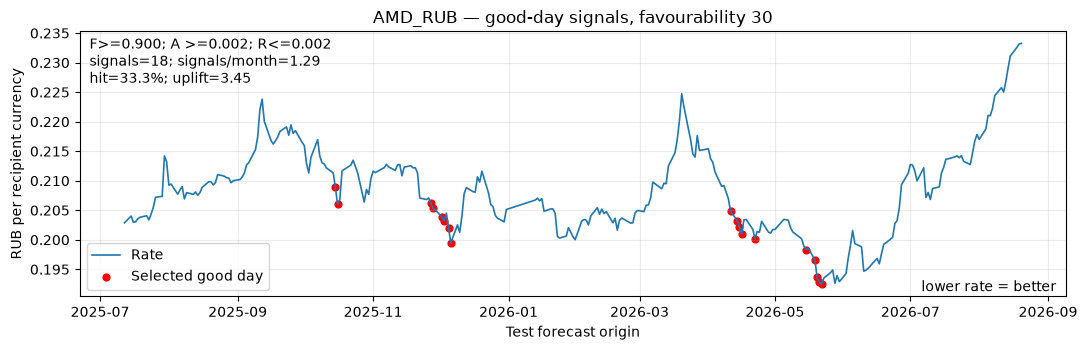

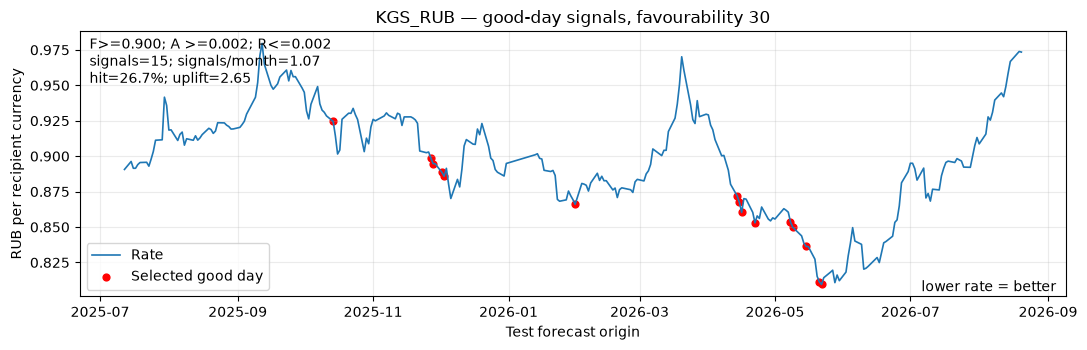

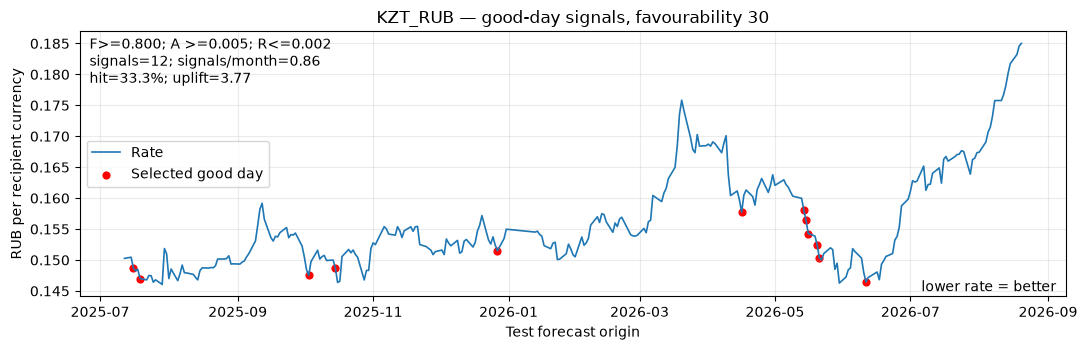

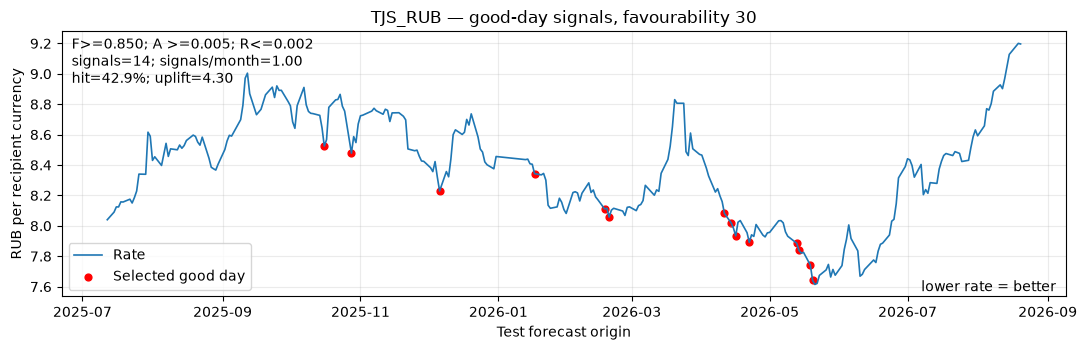

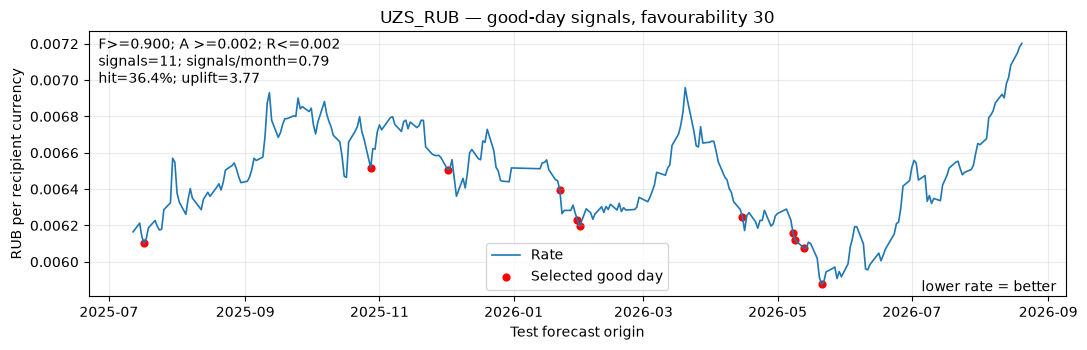

In [6]:
plot_test(run['predictions'],run['selection'],run['results'],ROOT/'reports/figures/favourability_30')

## 6. Leakage check

In [7]:
display(run['leakage'])
leakage_status='PASS' if run['leakage'].passed.all() else 'FAIL'
print('FAVOURABILITY 30 LEAKAGE CHECK:',leakage_status)

,check,passed
0,favourability_30 uses only T-30...T-1,True
1,current T excluded from percentile window,True
2,threshold selection validation only,True
3,test thresholds fixed,True
4,signal uses only approved live fields,True
5,actual regret only for GT/evaluation,True
6,no actual future rate in signal logic,True
7,one rule selected separately per corridor,True


FAVOURABILITY 30 LEAKAGE CHECK: PASS


## 7. Final summary

In [8]:
final=run['selection'].merge(run['results'],on=['corridor','selected_rule','F','A','R','status'])
display(final[['corridor','F','A','R','n_signals','mean_signals_per_month','hit_rate','uplift','status']].rename(columns={'n_signals':'test_signals'}))
comparison=run['comparison']
print(f"validated rule found: {run['selection'].status.eq('VALIDATED_RULE').sum()}/5")
print(f"test uplift > 1: {run['results'].uplift.gt(1).sum()}/5")
print(f"test uplift >= 1.3: {run['results'].uplift.ge(1.3).sum()}/5")
print(f"30-day gives more signals: {(comparison.new_test_signals>comparison.old_test_signals).sum()}/5")
print(f"30-day reduces zero-signal months: {(comparison.new_months_with_zero_signals<comparison.old_months_with_zero_signals).sum()}/5")
print('average uplift 30:',run['results'].uplift.mean())
print('average uplift 90:',comparison.old_uplift.mean())
print('Leakage:',leakage_status)
for name,path in run['paths'].items(): print(f'{name}: {path.relative_to(ROOT)}')

,corridor,F,A,R,test_signals,mean_signals_per_month,hit_rate,uplift,status
0,AMD_RUB,0.90,0.002,0.002,18,1.285714,0.333333,3.448276,VALIDATED_RULE
1,KGS_RUB,0.90,0.002,0.002,15,1.071429,0.266667,2.649007,VALIDATED_RULE
2,KZT_RUB,0.80,0.005,0.002,12,0.857143,0.333333,3.773585,VALIDATED_RULE
3,TJS_RUB,0.85,0.005,0.002,14,1.000000,0.428571,4.295943,VALIDATED_RULE
4,UZS_RUB,0.90,0.002,0.002,11,0.785714,0.363636,3.773585,VALIDATED_RULE


validated rule found: 5/5
test uplift > 1: 5/5
test uplift >= 1.3: 5/5
30-day gives more signals: 1/5
30-day reduces zero-signal months: 1/5
average uplift 30: 3.5880790033339998
average uplift 90: 3.9313687483738065
Leakage: PASS
selection: reports\favourability_30_rule_selection.csv
results: reports\favourability_30_test_results.csv
predictions: reports\favourability_30_predictions.csv
comparison: reports\favourability_30_vs_90.csv
report: reports\favourability_30_report.md
